# CascadeTorch: Results Visualization
Visualize spike rate predictions from pretrained CASCADE models.

In [1]:
import sys, os
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents):
    if (candidate / '.project-root').exists() or (
        (candidate / 'cascade2p').exists() and (candidate / 'Example_datasets').exists()
    ):
        project_root = str(candidate)
        break

if project_root is None:
    raise FileNotFoundError('Could not locate the CascadeTorch project root.')

if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.chdir(project_root)

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

# Set plot defaults
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

from cascade2p import cascade
from src.utils.noise import calculate_noise_levels

## 1. Load Example Data
Load Allen Brain Observatory calcium imaging data.

In [2]:
example_file = os.path.join(project_root, 'Example_datasets', 
    'Allen-Brain-Observatory-Visual-Coding-30Hz', 
    'Experiment_552195520_excerpt.mat')

traces = sio.loadmat(example_file)['dF_traces']
frame_rate = 30  # Hz

print(f"Loaded {traces.shape[0]} neurons, {traces.shape[1]} timepoints")
print(f"Frame rate: {frame_rate} Hz")
print(f"Duration: {traces.shape[1]/frame_rate:.1f} seconds")

Loaded 74 neurons, 6001 timepoints
Frame rate: 30 Hz
Duration: 200.0 seconds


## 2. Noise Level Distribution

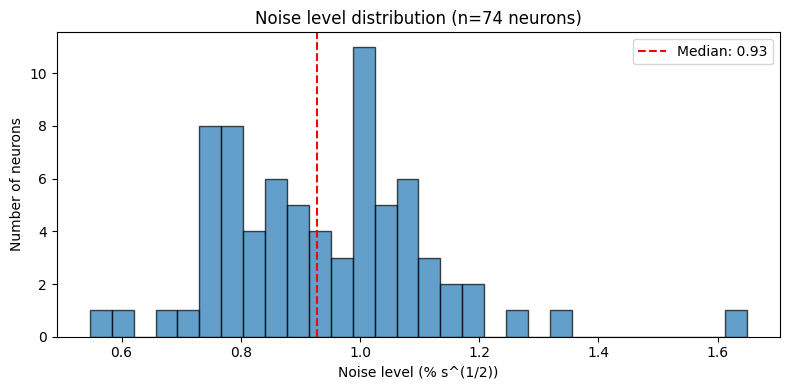

In [3]:
noise_levels = calculate_noise_levels(traces, frame_rate)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(noise_levels, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Noise level (% s^(1/2))')
ax.set_ylabel('Number of neurons')
ax.set_title(f'Noise level distribution (n={len(noise_levels)} neurons)')
ax.axvline(np.median(noise_levels), color='red', linestyle='--', label=f'Median: {np.median(noise_levels):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Run Inference with Pretrained Model

In [5]:
preferred_models = [
    'Global_EXC_30Hz_smoothing200ms',
    'Global_EXC_30Hz_smoothing100ms',
    'Global_EXC_30Hz_smoothing50ms',
    'Global_EXC_30Hz_smoothing25ms',
]

def model_has_weights(model_folder, model_name):
    folder = os.path.join(model_folder, model_name)
    if not os.path.isdir(folder):
        return False
    for root, _, files in os.walk(folder):
        if any(name.endswith('.pth') for name in files):
            return True
    return False

model_folder = os.path.join(project_root, 'Pretrained_models')
model_name = None

for candidate in preferred_models:
    if not model_has_weights(model_folder, candidate):
        try:
            cascade.download_model(candidate, model_folder=model_folder, verbose=1)
        except Exception:
            pass
    if model_has_weights(model_folder, candidate):
        model_name = candidate
        break

if model_name is None:
    raise FileNotFoundError('No usable pretrained 30 Hz model with .pth weights was found.')

# Run inference on the dF/F traces without additional rescaling
os.chdir(project_root)
spike_rates = cascade.predict(
    model_name,
    traces,
    model_folder=model_folder,
    verbosity=1,
 )
print(f'Using model: {model_name}')
print(f'Predictions shape: {spike_rates.shape}')

Pretrained model was saved in folder "/home/yz/spike_deconv/CascadeTorch/Pretrained_models/Global_EXC_30Hz_smoothing200ms"

 
The selected model was trained on 18 datasets, with 5 ensembles for each noise level, at a sampling rate of 30Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 200 milliseconds. 
 

Loaded model was trained at frame rate 30 Hz
Given argument traces contains 74 neurons and 6001 frames.
Noise levels (mean, std; in standard units): 0.93, 0.17

Predictions for noise level 1:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 2:
	... ensemble 0
	... ensemble 1
	... ensemble 2
	... ensemble 3
	... ensemble 4

Predictions for noise level 3:
	No neurons for this noise level

Predictions for noise level 4:
	No neurons for this noise level

Predictions for noise level 5:
	No neurons for this noise level

Predictions for noise level 6:
	No neurons for this noise le

## 4. Visualize Predictions

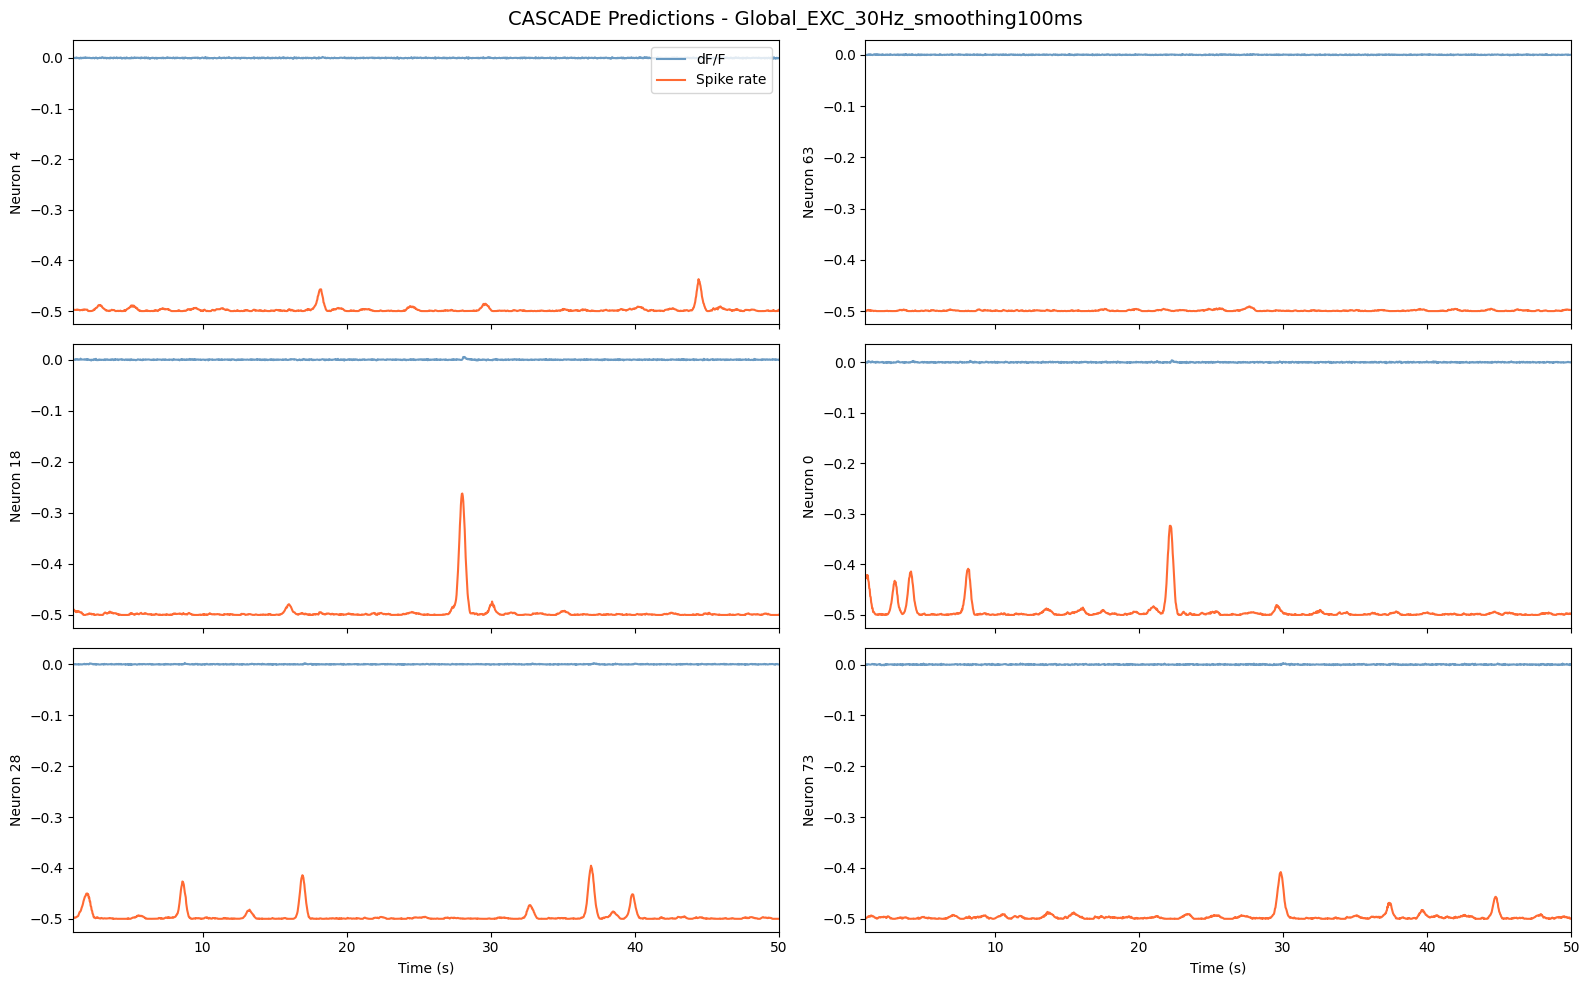

In [6]:
# Select 6 random neurons to display
np.random.seed(42)
neuron_indices = np.random.choice(traces.shape[0], size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
time = np.arange(traces.shape[1]) / frame_rate

for idx, (ax, neuron) in enumerate(zip(axes.flat, neuron_indices)):
    # Plot dF/F trace
    ax.plot(time, traces[neuron, :] / 100, color='steelblue', alpha=0.8, label='dF/F')
    
    # Plot spike rate prediction (shifted down for visibility)
    ax.plot(time, spike_rates[neuron, :] - 0.5, color='orangered', alpha=0.8, label='Spike rate')
    
    ax.set_ylabel(f'Neuron {neuron}')
    ax.set_xlim(1, min(50, traces.shape[1] / frame_rate - 1))
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
fig.suptitle(f'CASCADE Predictions - {model_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Prediction Statistics

Prediction Statistics:
  Mean spike rate:   0.0079
  Median spike rate: 0.0014
  Max spike rate:    0.7627
  Fraction zero:     16.49%
  Non-zero neurons:  74/74


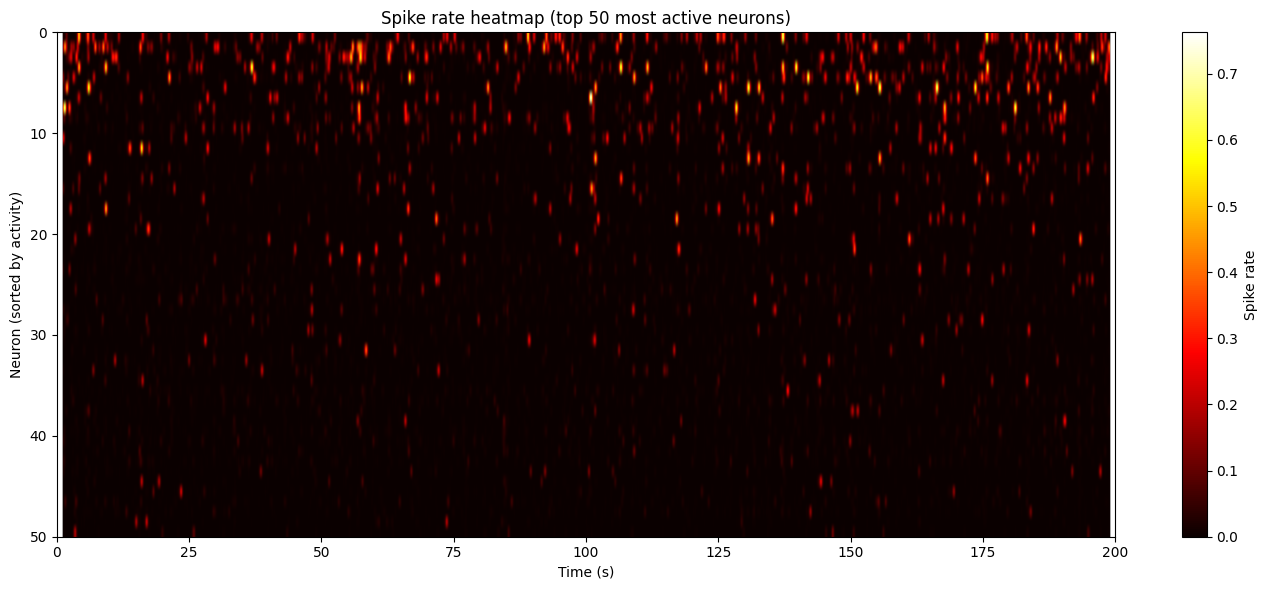

In [7]:
# Remove NaN padding for stats
valid = spike_rates[~np.isnan(spike_rates)]

print("Prediction Statistics:")
print(f"  Mean spike rate:   {np.mean(valid):.4f}")
print(f"  Median spike rate: {np.median(valid):.4f}")
print(f"  Max spike rate:    {np.max(valid):.4f}")
print(f"  Fraction zero:     {np.mean(valid == 0):.2%}")
print(f"  Non-zero neurons:  {np.sum(np.nanmax(spike_rates, axis=1) > 0)}/{spike_rates.shape[0]}")

# Heatmap of activity
fig, ax = plt.subplots(figsize=(14, 6))
# Sort neurons by total activity for better visualization
activity_order = np.argsort(np.nansum(spike_rates, axis=1))[::-1]
im = ax.imshow(spike_rates[activity_order[:50], :], aspect='auto', cmap='hot',
               extent=[0, traces.shape[1]/frame_rate, 50, 0])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron (sorted by activity)')
ax.set_title('Spike rate heatmap (top 50 most active neurons)')
plt.colorbar(im, ax=ax, label='Spike rate')
plt.tight_layout()
plt.show()

## 6. Model Comparison
Compare different smoothing parameters.

In [8]:
# This cell compares predictions from models with different smoothing
# Uncomment to run (requires downloading additional models)

# models_to_compare = [
#     'Global_EXC_30Hz_smoothing50ms',
#     'Global_EXC_30Hz_smoothing100ms', 
#     'Global_EXC_30Hz_smoothing200ms',
# ]

print("To compare models with different smoothing, uncomment the code above.")
print("Available experiment configs:")
for f in sorted(os.listdir(os.path.join(project_root, 'configs/experiment'))):
    if f.endswith('.yaml'):
        print(f"  - {f}")

To compare models with different smoothing, uncomment the code above.
Available experiment configs:
  - global_exc_30hz.yaml
  - global_exc_30hz_smoothing100ms.yaml
